# One-seed drift-aware phi rollout pilot

This notebook asks one narrow question: if `phi` is trained with a short **K-step** simulation of DriftXpress, does the frozen representation help the real 100-step Xpress drift?

The toy has 32 observed coordinates, but only two contain the cluster signal. `known_signal` is an oracle control that uses those two coordinates directly. `raw` uses all 32 coordinates. `rollout_phi` is trained without the oracle labels, using only target samples and the differentiable Xpress field.

This is a one-seed discovery run (`SEED=7`), not evidence of a general improvement. The external metrics are used only for evaluation; they are not backpropagated through phi.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import torch

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = (PROJECT_ROOT / '..').resolve()
if not (PROJECT_ROOT / 'src').exists():
    raise RuntimeError(f'Could not find src/ from {Path.cwd()}')
import os
os.chdir(PROJECT_ROOT)

from src.data import make_paired_run_inputs, make_toy_drift_problem
from src.diagnostics import plot_discrepancy_curves
from src.evaluators import DistributionEvaluator
from src.experiments import ExperimentConfig, run_comparison, seed_everything
from src.field import build_differentiable_xpress_cache, compute_xpress_field
from src.models import PhiNetwork
from src.representation import freeze_representation, validate_representation
from src.toy import run_particle_evolution


## Fixed toy protocol

Change these declarations first when you want a controlled follow-up. Keep `SEED=7` until the behavior is promising; only then repeat with several seeds.

In [2]:
SEED = 7
AMBIENT_DIM = 32
SIGNAL_DIM = 2
ROLLOUT_K = 10
PHI_STEPS = 200
DRIFT_STEPS = 200

TOY_KWARGS = dict(
    n_samples=512,
    ambient_dim=AMBIENT_DIM,
    signal_dim=SIGNAL_DIM,
    centers=8,
    cluster_std=0.6,
    nuisance_scale=1.0,
    initial_signal_scale=1.5,
)
PHI_KWARGS = dict(
    latent_dim=AMBIENT_DIM,
    feature_dim=SIGNAL_DIM,
    hidden_dims=(64, 64),
    residual=False,
)

seed_everything(SEED)
problem = make_toy_drift_problem(random_state=SEED, **TOY_KWARGS)
print('target shape:', tuple(problem.target.shape))
print('initial shape:', tuple(problem.initial.shape))
print('K:', ROLLOUT_K, '| phi steps:', PHI_STEPS, '| final drift steps:', DRIFT_STEPS)

target shape: (512, 32)
initial shape: (512, 32)
K: 10 | phi steps: 200 | final drift steps: 200


## Differentiable training split

The target samples are split once into (1) samples used to build the Xpress cache, (2) samples used by the training MMD loss, and (3) held-out samples used only by the final evaluator. This prevents the objective from reporting its own training target as the final result.

In [3]:
split_generator = torch.Generator(device='cpu').manual_seed(SEED + 5000)
permutation = torch.randperm(problem.target.shape[0], generator=split_generator)
TRAIN_SIZE = 256
LOSS_SIZE = 128
train_indices = permutation[:TRAIN_SIZE]
loss_indices = permutation[TRAIN_SIZE:TRAIN_SIZE + LOSS_SIZE]
eval_indices = permutation[TRAIN_SIZE + LOSS_SIZE:]
target_train = problem.target[train_indices].detach()
target_for_loss = problem.target[loss_indices].detach()
target_for_eval = problem.target[eval_indices].detach()
landmark_indices = torch.randperm(TRAIN_SIZE, generator=split_generator)[:64]
initial_probe = problem.initial[:128].detach()

def median_bandwidth(values):
    distances = torch.pdist(values.float())
    nonzero = distances[distances > 0]
    return nonzero.median().clamp_min(1e-3) if nonzero.numel() else values.new_tensor(1.0)

def torch_mmd_rbf(x, y, bandwidth):
    bandwidth = torch.as_tensor(bandwidth, device=x.device, dtype=x.dtype).clamp_min(1e-6)
    k_xx = torch.exp(-torch.cdist(x.float(), x.float()).pow(2) / (2 * bandwidth.pow(2)))
    k_yy = torch.exp(-torch.cdist(y.float(), y.float()).pow(2) / (2 * bandwidth.pow(2)))
    k_xy = torch.exp(-torch.cdist(x.float(), y.float()).pow(2) / (2 * bandwidth.pow(2)))
    return k_xx.mean() + k_yy.mean() - 2 * k_xy.mean()

LOSS_BANDWIDTH = median_bandwidth(target_for_loss)
print('cache samples:', len(target_train), '| loss samples:', len(target_for_loss), '| held-out samples:', len(target_for_eval))
print('RBF bandwidth:', round(float(LOSS_BANDWIDTH), 4))

cache samples: 256 | loss samples: 128 | held-out samples: 128
RBF bandwidth: 13.7244


## The K-step objective

`K` counts repeated *hypothetical* particle updates inside one phi optimizer step. For `K=5`, start from the same probe state `z_0`, compute five Xpress fields, and evaluate MMD only at `z_5`. The cache is built once while phi is fixed and reused through the five updates; after phi changes, the cache is rebuilt.

This is different from the final drift length (`DRIFT_STEPS=100`). The final experiment freezes phi and then performs the ordinary cached Xpress evolution.

In [4]:
def train_phi_with_rollout(*, rollout_steps, steps):
    seed_everything(SEED + 3500 + rollout_steps)
    phi = PhiNetwork(**PHI_KWARGS)
    optimizer = torch.optim.Adam(phi.parameters(), lr=1e-3)
    history = []
    phi.train()
    for phi_step in range(steps):
        cache = build_differentiable_xpress_cache(
            target_train,
            landmark_indices=landmark_indices,
            temperature=1.0,
            representation=phi,
        )
        probe = initial_probe
        field = None
        for _ in range(rollout_steps):
            field = compute_xpress_field(probe, cache=cache, representation=phi)
            probe = probe + 0.1 * field
        loss = torch_mmd_rbf(probe, target_for_loss, LOSS_BANDWIDTH)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(phi.parameters(), max_norm=10.0)
        optimizer.step()
        history.append({
            'step': phi_step + 1,
            'loss': float(loss.detach()),
            'field_norm': float(field.detach().norm(dim=1).mean()),
        })
    freeze_representation(phi)
    return phi, history

rollout_phi, rollout_history = train_phi_with_rollout(
    rollout_steps=ROLLOUT_K,
    steps=PHI_STEPS,
)
rollout_health = validate_representation(phi=rollout_phi, fixed_latents=problem.target)
print('K-step proxy loss:', round(rollout_history[0]['loss'], 5), '->', round(rollout_history[-1]['loss'], 5))
print('frozen phi health:', rollout_health)

K-step proxy loss: 0.01549 -> 0.00114
frozen phi health: RepresentationHealthReport(mean_feature_std=1.6331535577774048, minimum_feature_std=1.434762716293335, pairwise_distance_correlation=0.30199098587036133, effective_rank=1.7858489751815796)


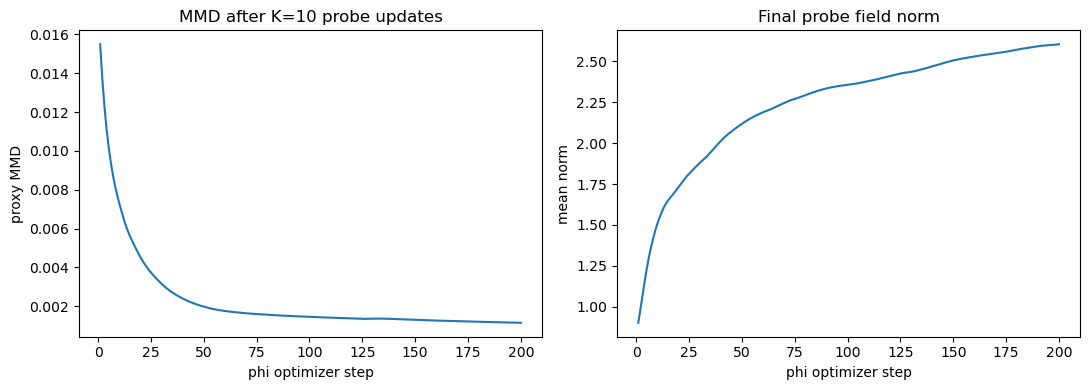

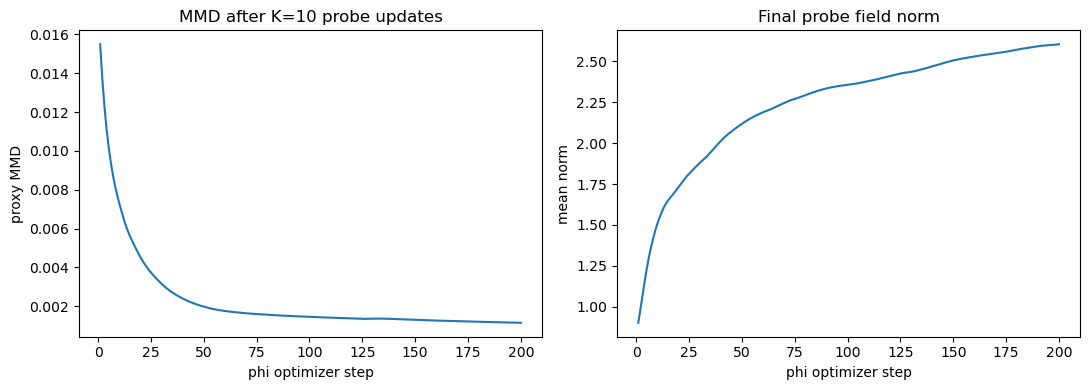

In [5]:
figure, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot([item['step'] for item in rollout_history], [item['loss'] for item in rollout_history])
axes[0].set(title=f'MMD after K={ROLLOUT_K} probe updates', xlabel='phi optimizer step', ylabel='proxy MMD')
axes[1].plot([item['step'] for item in rollout_history], [item['field_norm'] for item in rollout_history])
axes[1].set(title='Final probe field norm', xlabel='phi optimizer step', ylabel='mean norm')
figure.tight_layout()
display(figure)

## Optional one-step comparison

Training a second representation with `K=1` gives a direct diagnostic: if K=5 behaves better than K=1 on the same final drift, repeated-horizon feedback may matter. This is still one seed and remains exploratory.

In [6]:
one_step_phi, one_step_history = train_phi_with_rollout(rollout_steps=1, steps=PHI_STEPS)
print('K=1 proxy loss:', round(one_step_history[0]['loss'], 5), '->', round(one_step_history[-1]['loss'], 5))
print('K=1 frozen phi health:', validate_representation(phi=one_step_phi, fixed_latents=problem.target))

K=1 proxy loss: 0.02052 -> 0.00744
K=1 frozen phi health: RepresentationHealthReport(mean_feature_std=4.5969557762146, minimum_feature_std=3.9232733249664307, pairwise_distance_correlation=0.1606806516647339, effective_rank=1.903826117515564)


## Frozen 100-step external comparison

Every method below receives the same target-index schedule and initial particles. `raw` and `known_signal` are controls; the learned representations are frozen. The evaluator uses held-out target samples and is never part of phi training.

known_signal: final signal SWD=0.5742; AUC=136.3882
one_step_phi: final signal SWD=12.9540; AUC=887.5655
raw: final signal SWD=1.4717; AUC=241.3610
rollout_phi: final signal SWD=2.7854; AUC=350.1273


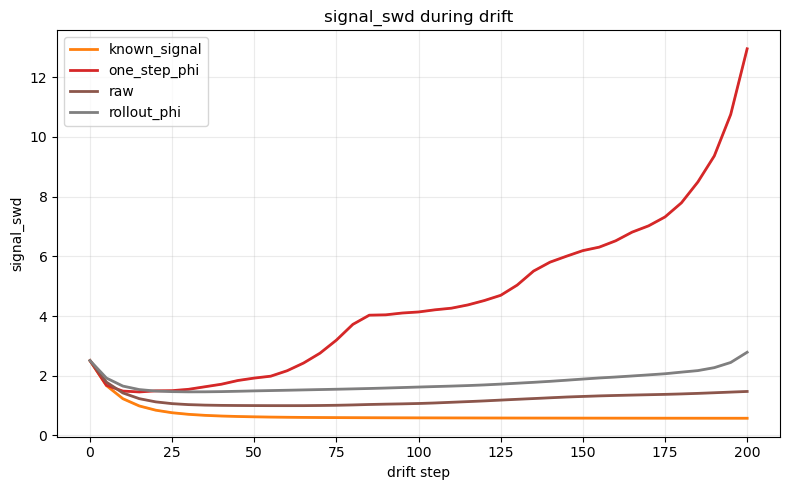

[{'method': 'known_signal',
  'n_seeds': 1,
  'final_mean': 0.5741912935735485,
  'final_std': 0.0,
  'auc_mean': 136.38824656233476,
  'auc_std': 0.0,
  'fixed_budget_mean': 0.5741912935735485,
  'fixed_budget_std': 0.0},
 {'method': 'one_step_phi',
  'n_seeds': 1,
  'final_mean': 12.954020714898014,
  'final_std': 0.0,
  'auc_mean': 887.5655228506394,
  'auc_std': 0.0,
  'fixed_budget_mean': 12.954020714898014,
  'fixed_budget_std': 0.0},
 {'method': 'raw',
  'n_seeds': 1,
  'final_mean': 1.471658128561136,
  'final_std': 0.0,
  'auc_mean': 241.36099611522798,
  'auc_std': 0.0,
  'fixed_budget_mean': 1.471658128561136,
  'fixed_budget_std': 0.0},
 {'method': 'rollout_phi',
  'n_seeds': 1,
  'final_mean': 2.785362141196979,
  'final_std': 0.0,
  'auc_mean': 350.1272516487296,
  'auc_std': 0.0,
  'fixed_budget_mean': 2.785362141196979,
  'fixed_budget_std': 0.0}]

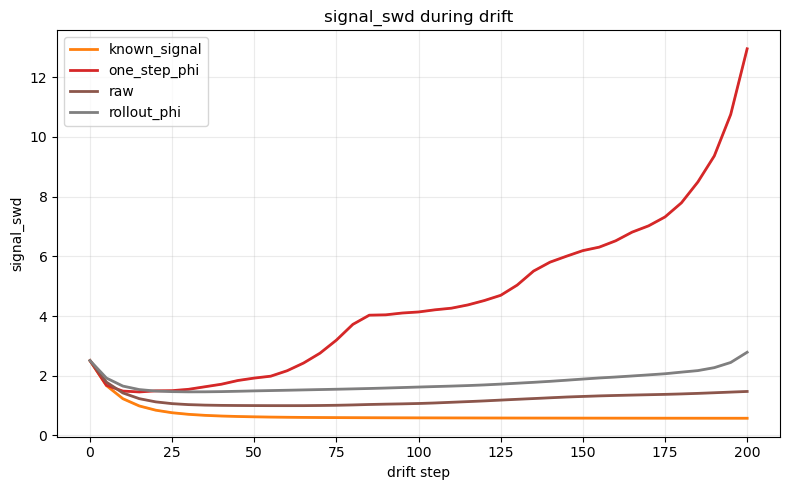

In [7]:
CONFIG = ExperimentConfig(
    dataset='toy32',
    methods=('raw', 'known_signal', 'one_step_phi', 'rollout_phi'),
    seeds=(SEED,),
    drift_steps=DRIFT_STEPS,
    eval_every=5,
    primary_metric='signal_swd',
    fixed_budget=DRIFT_STEPS,
)

def paired_factory(seed):
    return make_paired_run_inputs(
        n_steps=DRIFT_STEPS,
        dataset_size=TOY_KWARGS['n_samples'],
        batch_size=256,
        noise_dim=1,
        n_landmarks=128,
        evaluation_size=1,
        seed=seed,
    )

def heldout_evaluator(run_problem):
    views = {'observed': lambda values: values, 'signal': run_problem.project_signal}
    if run_problem.nuisance_projection.shape[1] > 0:
        views['nuisance'] = run_problem.project_nuisance
    return DistributionEvaluator(target_for_eval, views=views, metrics=('swd', 'mmd'), random_state=1234)

def run_one(config, method, seed, paired_inputs):
    run_problem = make_toy_drift_problem(random_state=seed, **TOY_KWARGS)
    representation = {
        'raw': None,
        'known_signal': run_problem.project_signal,
        'one_step_phi': one_step_phi,
        'rollout_phi': rollout_phi,
    }[method]
    return run_particle_evolution(
        problem=run_problem,
        paired_inputs=paired_inputs,
        representation=representation,
        evaluator=heldout_evaluator(run_problem),
        method=method,
        seed=seed,
        temperature=1.0,
        step_size=0.1,
        eval_every=CONFIG.eval_every,
        backend='xpress',
        output_dir=None,
    )

comparison = run_comparison(CONFIG, run_one=run_one, paired_factory=paired_factory)
for row in comparison.summary:
    print(f"{row['method']}: final signal SWD={row['final_mean']:.4f}; AUC={row['auc_mean']:.4f}")

figure, axis = plot_discrepancy_curves(comparison, metric_name='signal_swd', show_individual_seeds=True)
display(figure)
comparison.summary

## What to inspect before changing anything

1. Did the K-step proxy loss decrease?
2. Did the frozen phi health report show nonzero feature spread and a sensible effective rank?
3. On the external 100-step curve, did `rollout_phi` beat `raw` in signal SWD or AUC?
4. Did K=5 beat K=1, or did both fail similarly?

If the proxy decreases but the external curve does not improve, the objective is still misaligned. Do not tune many parameters yet: change one objective ingredient or inspect the field geometry first.

## Diagnostic: did phi learn the known signal?

This section does not train anything and does not change the drift comparison. It uses the held-out target split to ask whether each representation preserves the two known signal coordinates. A linear-probe R2 near 1 means the signal is recoverable from the representation; a low value means the current objective did not learn the signal. The nuisance score is a guardrail, not a training target.

raw: signal R2=1.000; nuisance R2=1.000
known_signal: signal R2=1.000; nuisance R2=-0.078
K=1 phi: signal R2=0.182; nuisance R2=-0.044
K=10 phi: signal R2=0.237; nuisance R2=-0.055


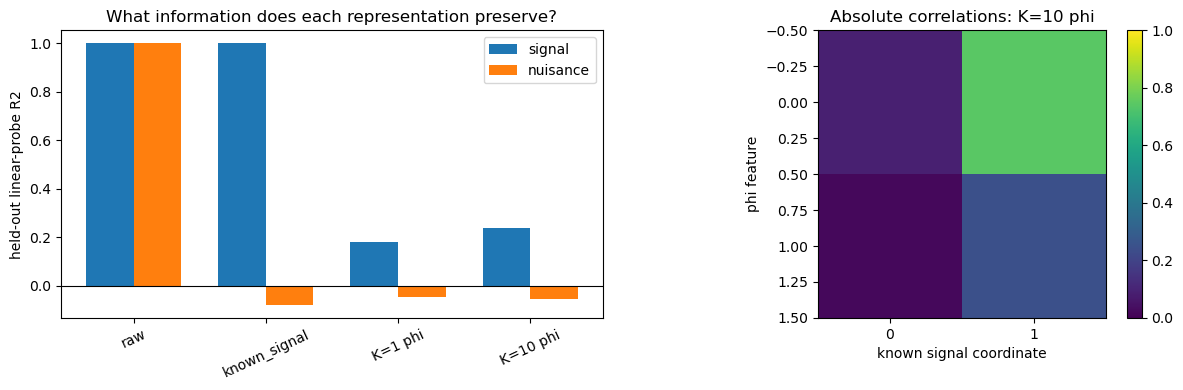

Read signal R2 as: can the known signal be reconstructed from phi? This diagnostic is not a training objective.


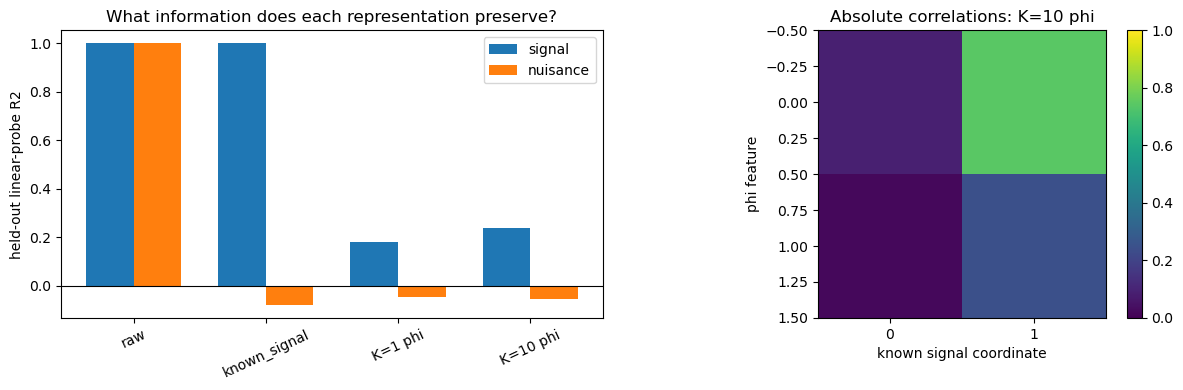

In [8]:
def linear_probe_r2(features, targets):
    features = features.detach().float()
    targets = targets.detach().float()
    split = features.shape[0] // 2
    x_train = torch.cat([torch.ones(split, 1), features[:split]], dim=1)
    x_test = torch.cat([torch.ones(features.shape[0] - split, 1), features[split:]], dim=1)
    coefficients = torch.linalg.lstsq(x_train, targets[:split]).solution
    prediction = x_test @ coefficients
    residual = (targets[split:] - prediction).pow(2).sum(dim=0)
    centered = targets[split:] - targets[split:].mean(dim=0, keepdim=True)
    total = centered.pow(2).sum(dim=0).clamp_min(1e-8)
    return float((1.0 - residual / total).mean())

def feature_signal_correlation(features, signal):
    features = features.detach().float() - features.detach().float().mean(dim=0, keepdim=True)
    signal = signal.detach().float() - signal.detach().float().mean(dim=0, keepdim=True)
    numerator = features.T @ signal
    denominator = torch.sqrt(features.pow(2).sum(dim=0)[:, None] * signal.pow(2).sum(dim=0)[None, :]).clamp_min(1e-8)
    return numerator / denominator

diagnostic_z = target_for_eval
diagnostic_signal = problem.project_signal(diagnostic_z)
diagnostic_nuisance = problem.project_nuisance(diagnostic_z)
diagnostic_representations = {
    'raw': diagnostic_z,
    'known_signal': diagnostic_signal,
    'K=1 phi': one_step_phi(diagnostic_z),
    f'K={ROLLOUT_K} phi': rollout_phi(diagnostic_z),
}

diagnostic_rows = []
diagnostic_correlations = {}
for name, features in diagnostic_representations.items():
    signal_r2 = linear_probe_r2(features, diagnostic_signal)
    nuisance_r2 = linear_probe_r2(features, diagnostic_nuisance)
    diagnostic_rows.append({'method': name, 'signal_r2': signal_r2, 'nuisance_r2': nuisance_r2})
    diagnostic_correlations[name] = feature_signal_correlation(features, diagnostic_signal)
    print(f'{name}: signal R2={signal_r2:.3f}; nuisance R2={nuisance_r2:.3f}')

figure, axes = plt.subplots(1, 2, figsize=(12, 4))
positions = torch.arange(len(diagnostic_rows))
axes[0].bar(positions - 0.18, [row['signal_r2'] for row in diagnostic_rows], width=0.36, label='signal')
axes[0].bar(positions + 0.18, [row['nuisance_r2'] for row in diagnostic_rows], width=0.36, label='nuisance')
axes[0].axhline(0.0, color='black', linewidth=0.8)
axes[0].set(xticks=positions, xticklabels=[row['method'] for row in diagnostic_rows], ylabel='held-out linear-probe R2', title='What information does each representation preserve?')
axes[0].tick_params(axis='x', rotation=25)
axes[0].legend()
rollout_name = f'K={ROLLOUT_K} phi'
correlation_image = diagnostic_correlations[rollout_name].abs().numpy()
image = axes[1].imshow(correlation_image, vmin=0.0, vmax=1.0, cmap='viridis')
axes[1].set(xticks=range(SIGNAL_DIM), xlabel='known signal coordinate', ylabel='phi feature', title=f'Absolute correlations: {rollout_name}')
figure.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04)
figure.tight_layout()
display(figure)
print('Read signal R2 as: can the known signal be reconstructed from phi? This diagnostic is not a training objective.')